<a href="https://colab.research.google.com/github/srinivas019/TCN-TASKS/blob/main/salary_pred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [201]:
import pandas as pd
url= "https://raw.githubusercontent.com/Pranjali1049/Salary_Prediction/main/Salary_Data.csv"
df=pd.read_csv(url)
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [202]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [208]:
df_clean = df.dropna(subset=["Years of Experience", "Salary"])

In [238]:
X = df_clean[["Years of Experience"]]
y = df_clean["Salary"]

X.head()
y.head()

,Salary
0,90000.0
1,65000.0
2,150000.0
3,60000.0
4,200000.0


In [226]:
print(X.isnull().sum())
print(y.isnull().sum())

Years of Experience    0
dtype: int64
0


In [228]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [229]:
print(X_train.isnull().sum())
print(X_test.isnull().sum())

Years of Experience    0
dtype: int64
Years of Experience    0
dtype: int64


In [217]:
print(X_train.shape)
print(X_test.shape)

(5363, 1)
(1341, 1)


In [219]:
print(X_train.isnull().sum())
print(X_train.shape)

Years of Experience    1
dtype: int64
(5363, 1)


In [231]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

pred=model.predict(X_test)
pred

array([ 72483.49432794, 114739.69696666,  79526.19476772, ...,
        65440.79388815,  79526.19476772,  58398.09344836])

In [233]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 24722.101443221916


In [234]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, pred)
print("R-squared:", r2)

R-squared: 0.6669549610495003


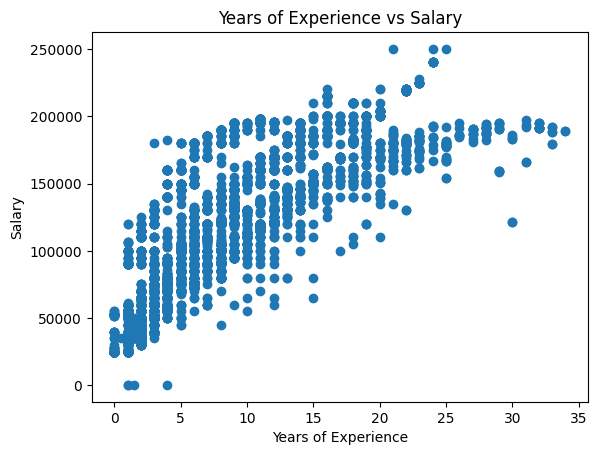

In [239]:
import matplotlib.pyplot as plt

plt.scatter(X, y)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Years of Experience vs Salary")
plt.show()